In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta

from Math.lm_class import LinearModel, kalman, kalman1d, OnlineScoring
from Math.accumfeatures import MSTD
from sklearn.preprocessing import StandardScaler
from Math.ti_class import TI_class, TR_class
from Database.TPData import TPData, TPDataDa
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import r2_score

In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data preparation

In [33]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_july.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_july.csv',
                    parse_dates=['datetime']).reset_index()

In [34]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [35]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [36]:
# data_lead['time_diff']=data_lead['datetime'].diff().dt.total_seconds().fillna(0)
# data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [37]:
del data_lag['index']
del data_lead['index']
del data_lag['trd_side']
del data_lead['trd_side']

In [38]:
data_lag.head()

,datetime,trd_price,volume,bid_price,ask_price,mid_price
469,2024-07-01 09:00:06.000000000,NaN,NaN,84.57,85.59,85.08
470,2024-07-01 09:00:07.000000000,NaN,NaN,84.59,85.59,85.09
471,2024-07-01 09:00:08.673907280,85.59,2.0,84.59,85.59,85.09
472,2024-07-01 09:00:09.000000000,NaN,NaN,84.61,85.59,85.10
473,2024-07-01 09:00:10.124257326,85.59,1.0,84.61,85.59,85.10


In [39]:
data_lead.head()

,datetime,trd_price,volume,bid_price,ask_price,mid_price
123,2024-07-01 09:00:05.687479496,77.78,1.0,76.90,77.78,77.34
124,2024-07-01 09:00:10.607145071,77.78,1.0,77.00,77.78,77.39
125,2024-07-01 09:00:21.248078108,77.87,8.0,77.17,77.87,77.52
126,2024-07-01 09:01:07.907927752,77.93,6.0,77.51,77.93,77.72
127,2024-07-01 09:01:07.907927752,77.95,1.0,77.51,77.93,77.72


## Filtering out only trades

In [40]:
def deduplicate_trades(df):
    cols=df.columns
    
    df['pv']=df['trd_price']*df['volume']
    df=df.groupby('datetime').agg({
    'pv': 'sum',
    #'trd_price': 'sum',    # Mean of 'trd_price'
    'volume': 'sum',        # Sum of 'volume'
    'bid_price': 'mean',     # Max of 'bid_price'
    'ask_price': 'mean',     # Min of 'ask_price'
    'mid_price': 'mean',  # Median of 'mid_price'
    #'time_diff': 'std'      # Standard deviation of 'time_diff'
})
    df['trd_price']=df['pv']/df['volume']
    
    return df[cols]

In [41]:
data_lead_trds=deduplicate_trades(data_lead[data_lead['trd_price'].isnull()==False].set_index('datetime', inplace=False))
data_lag_trds=deduplicate_trades(data_lag[data_lag['trd_price'].isnull()==False].set_index('datetime', inplace=False))

In [42]:
data_lead_trds['tag']='lead'
data_lag_trds['tag']='lag'

df_trds=pd.concat([data_lead_trds, data_lag_trds]).sort_index()

df_trds['lead_price']=df_trds[['trd_price','tag']].apply(lambda row: row['trd_price'] if row['tag'] == 'lead' else None, axis=1)
df_trds['lead_volume']=df_trds[['volume','tag']].apply(lambda row: row['volume'] if row['tag'] == 'lead' else None, axis=1)
df_trds['lead_pv']=df_trds[['trd_price', 'volume','tag']].apply(lambda row: row['trd_price']*row['volume'] if row['tag'] == 'lead' else None, axis=1)

df_trds['lag_price']=df_trds[['trd_price','tag']].apply(lambda row: row['trd_price'] if row['tag'] == 'lag' else None, axis=1)
df_trds['lag_volume']=df_trds[['volume','tag']].apply(lambda row: row['volume'] if row['tag'] == 'lag' else None, axis=1)
df_trds['lag_pv']=df_trds[['trd_price', 'volume','tag']].apply(lambda row: row['trd_price']*row['volume'] if row['tag'] == 'lag' else None, axis=1)

## Preparing tick data

In [43]:
tau = 10
tau_ema = 10

In [44]:
ti_cls = TR_class(tau, tau_ema)

In [45]:
agg_dict = {'index': 'first'}
agg_dict.update({k: 'sum' for k in ['lead_volume', 'lead_pv', 'lag_volume', 'lag_pv']})

df_trds['date']= df_trds.index.date
dates_list=sorted(list(set(df_trds['date'])))

df_list=[]
df_list2=[]

for current_day in dates_list:
    df_trds_1day=df_trds[df_trds['date']==current_day]
    idx_series = ti_cls.tick_imbalance_indices(df_trds_1day.loc[:,'lag_price'])
    # Create returns
    df_trds_indexed_1day = pd.concat([df_trds_1day.reindex(idx_series.index), idx_series], axis=1).reset_index()
    df_trds_indexed_1day['tick_id'] = str(current_day)+'_'+df_trds_indexed_1day[0].fillna(0).apply(str)
    df_trds_indexed_1day['datetime']=df_trds_indexed_1day['index']
    df_trds_indexed_1day=df_trds_indexed_1day.set_index('datetime')
    df_trds_indexed_1day_grouped = df_trds_indexed_1day.groupby('tick_id').agg(agg_dict).reset_index().set_index('index')
    
    df_trds_indexed_1day_grouped['lead_price']=df_trds_indexed_1day_grouped['lead_pv']/df_trds_indexed_1day_grouped['lead_volume']
    df_trds_indexed_1day_grouped['lag_price']=df_trds_indexed_1day_grouped['lag_pv']/df_trds_indexed_1day_grouped['lag_volume']
    
    df_trds_indexed_1day_grouped['lead_log_ret']=np.log(df_trds_indexed_1day_grouped['lead_price'].fillna(method='ffill')).diff()
    df_trds_indexed_1day_grouped['lag_log_ret']=np.log(df_trds_indexed_1day_grouped['lag_price'].fillna(method='ffill')).diff()
    df_list.append(df_trds_indexed_1day_grouped)
    df_list2.append(df_trds_indexed_1day['tick_id'])

df_trds_indexed=pd.concat(df_list).sort_index()
df_trds=df_trds.merge(pd.concat(df_list2).sort_index(), left_index=True, right_index=True, how='left')

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1740069129.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_trds_indexed_1day_grouped['lead_log_ret']=np.log(df_trds_indexed_1day_grouped['lead_price'].fillna(method='ffill')).diff()
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1740069129.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_trds_indexed_1day_grouped['lag_log_ret']=np.log(df_trds_indexed_1day_grouped['lag_price'].fillna(method='ffill')).diff()
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1740069129.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_trds_indexed_1day_grouped['lead_log_ret']=np.log(df_trds_indexed_1day_grouped['lead_price'].fillna(method='ffill')).diff()
C:\Users\andrej

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1740069129.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_trds_indexed_1day_grouped['lead_log_ret']=np.log(df_trds_indexed_1day_grouped['lead_price'].fillna(method='ffill')).diff()
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1740069129.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_trds_indexed_1day_grouped['lag_log_ret']=np.log(df_trds_indexed_1day_grouped['lag_price'].fillna(method='ffill')).diff()
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1740069129.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_trds_indexed_1day_grouped['lead_log_ret']=np.log(df_trds_indexed_1day_grouped['lead_price'].fillna(method='ffill')).diff()
C:\Users\andrej

In [46]:
df_trds_indexed

,tick_id,lead_volume,lead_pv,lag_volume,lag_pv,lead_price,lag_price,lead_log_ret,lag_log_ret
index,,,,,,,,,
2024-07-01 09:00:05.687479496,2024-07-01_0.0,69.0,5373.89,12.0,1028.10,77.882464,85.675000,NaN,NaN
2024-07-01 09:12:06.067290306,2024-07-01_1.0,0.0,0.00,2.0,171.96,NaN,85.980000,0.000000,0.003554
2024-07-01 09:12:08.022298574,2024-07-01_2.0,32.0,2497.98,9.0,774.32,78.061875,86.035556,0.016690,0.018009
2024-07-01 09:14:56.361129522,2024-07-01_3.0,148.0,11584.75,21.0,1812.93,78.275338,86.330000,0.027965,0.030317
2024-07-01 09:45:47.741413832,2024-07-01_4.0,83.0,6483.22,12.0,1034.04,78.111084,86.170000,0.032462,0.034886
...,...,...,...,...,...,...,...,...,...
2024-07-31 17:10:16.046613693,2024-07-31_35.0,90.0,7551.27,8.0,689.38,83.903000,86.172500,0.000344,0.001113
2024-07-31 17:27:01.455563307,2024-07-31_36.0,77.0,6457.52,6.0,517.33,83.863896,86.221667,-0.000466,0.000570
2024-07-31 17:36:41.932906151,2024-07-31_37.0,30.0,2508.54,10.0,859.08,83.618000,85.908000,-0.002936,-0.003645


In [47]:
df_trds

,trd_price,volume,bid_price,ask_price,mid_price,tag,lead_price,lead_volume,lead_pv,lag_price,lag_volume,lag_pv,date,tick_id
datetime,,,,,,,,,,,,,,
2024-07-01 09:00:05.687479496,77.78,1.0,76.90,77.78,77.34,lead,77.78,1.0,77.78,NaN,NaN,NaN,2024-07-01,2024-07-01_0.0
2024-07-01 09:00:08.673907280,85.59,2.0,84.59,85.59,85.09,lag,NaN,NaN,NaN,85.59,2.0,171.18,2024-07-01,2024-07-01_0.0
2024-07-01 09:00:10.124257326,85.59,1.0,84.61,85.59,85.10,lag,NaN,NaN,NaN,85.59,1.0,85.59,2024-07-01,2024-07-01_0.0
2024-07-01 09:00:10.124334812,85.59,1.0,84.61,85.59,85.10,lag,NaN,NaN,NaN,85.59,1.0,85.59,2024-07-01,2024-07-01_0.0
2024-07-01 09:00:10.607145071,77.78,1.0,77.00,77.78,77.39,lead,77.78,1.0,77.78,NaN,NaN,NaN,2024-07-01,2024-07-01_0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-31 17:59:24.314107895,83.62,1.0,83.63,83.69,83.66,lead,83.62,1.0,83.62,NaN,NaN,NaN,2024-07-31,2024-07-31_39.0
2024-07-31 17:59:24.314178467,83.61,1.0,83.63,83.69,83.66,lead,83.61,1.0,83.61,NaN,NaN,NaN,2024-07-31,2024-07-31_39.0
2024-07-31 17:59:26.323147058,85.90,1.0,85.88,85.96,85.92,lag,NaN,NaN,NaN,85.90,1.0,85.90,2024-07-31,2024-07-31_39.0


# Model fitting and scoring

Summary for model on 2024-07-08:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     6391.
Date:                Thu, 22 Aug 2024   Prob (F-statistic):          1.57e-232
Time:                        13:01:55   Log-Likelihood:                 1810.5
No. Observations:                 365   AIC:                            -3617.
Df Residuals:                     363   BIC:                            -3609.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


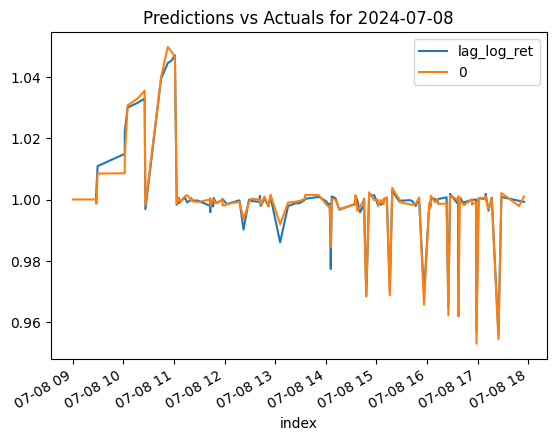

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-09:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     2674.
Date:                Thu, 22 Aug 2024   Prob (F-statistic):          5.56e-185
Time:                        13:01:56   Log-Likelihood:                 1844.1
No. Observations:                 425   AIC:                            -3684.
Df Residuals:                     423   BIC:                            -3676.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         3

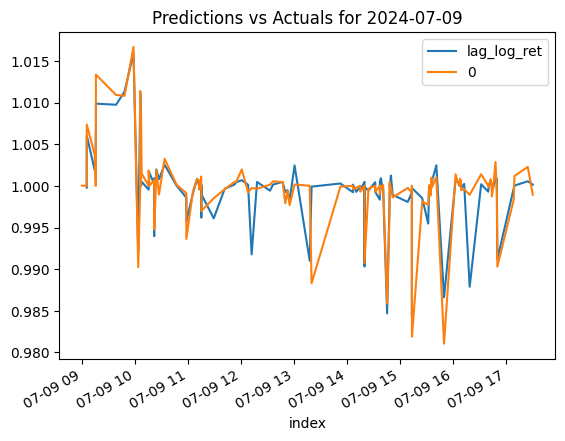

Summary for model on 2024-07-10:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.799
Method:                 Least Squares   F-statistic:                     1753.
Date:                Thu, 22 Aug 2024   Prob (F-statistic):          2.25e-155
Time:                        13:01:56   Log-Likelihood:                 1863.1
No. Observations:                 441   AIC:                            -3722.
Df Residuals:                     439   BIC:                            -3714.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


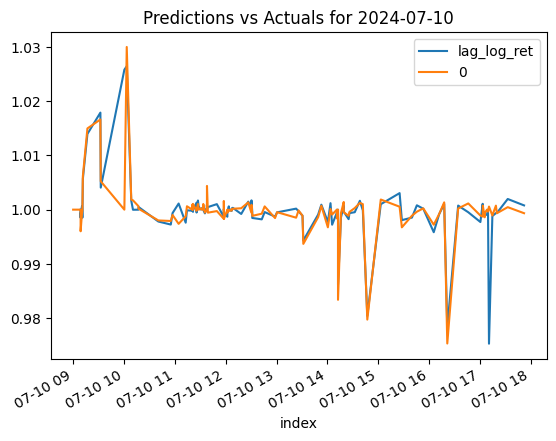

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-11:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     1699.
Date:                Thu, 22 Aug 2024   Prob (F-statistic):          9.91e-161
Time:                        13:01:56   Log-Likelihood:                 2032.6
No. Observations:                 488   AIC:                            -4061.
Df Residuals:                     486   BIC:                            -4053.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1

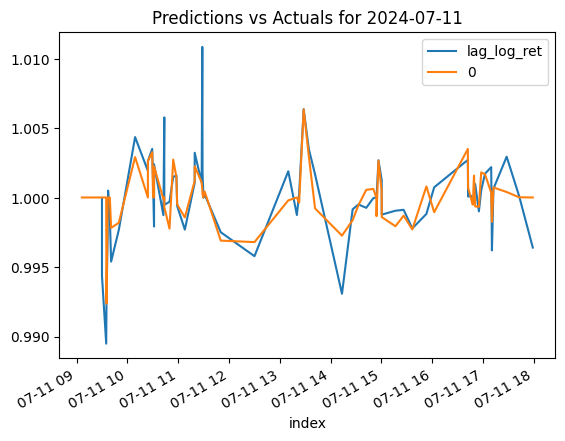

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-12:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     1589.
Date:                Thu, 22 Aug 2024   Prob (F-statistic):          9.00e-158
Time:                        13:01:56   Log-Likelihood:                 2110.7
No. Observations:                 505   AIC:                            -4217.
Df Residuals:                     503   BIC:                            -4209.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2

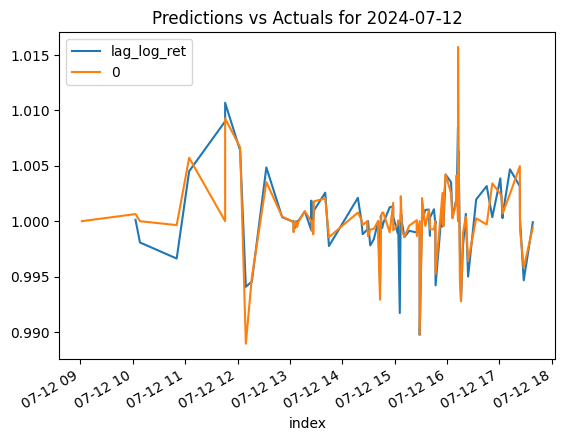

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-15:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     1664.
Date:                Thu, 22 Aug 2024   Prob (F-statistic):          6.90e-168
Time:                        13:01:56   Log-Likelihood:                 2297.8
No. Observations:                 548   AIC:                            -4592.
Df Residuals:                     546   BIC:                            -4583.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -4

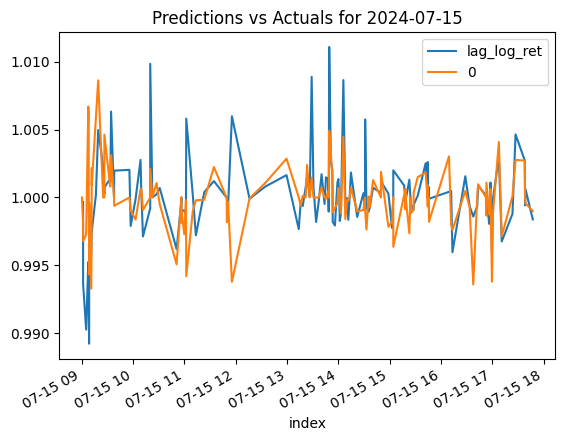

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-16:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     465.1
Date:                Thu, 22 Aug 2024   Prob (F-statistic):           1.30e-75
Time:                        13:01:56   Log-Likelihood:                 2482.5
No. Observations:                 564   AIC:                            -4961.
Df Residuals:                     562   BIC:                            -4952.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2

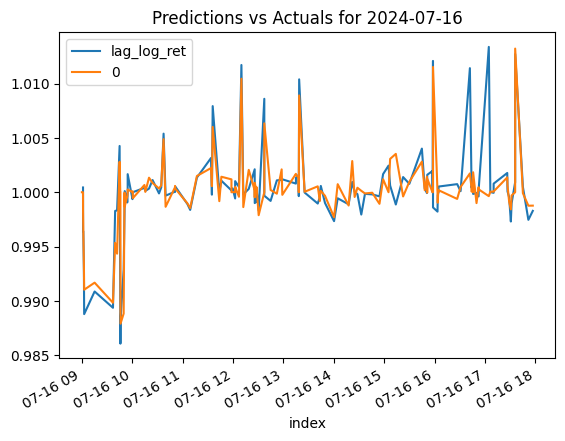

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-17:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.460
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     485.7
Date:                Thu, 22 Aug 2024   Prob (F-statistic):           2.37e-78
Time:                        13:01:56   Log-Likelihood:                 2539.0
No. Observations:                 573   AIC:                            -5074.
Df Residuals:                     571   BIC:                            -5065.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1

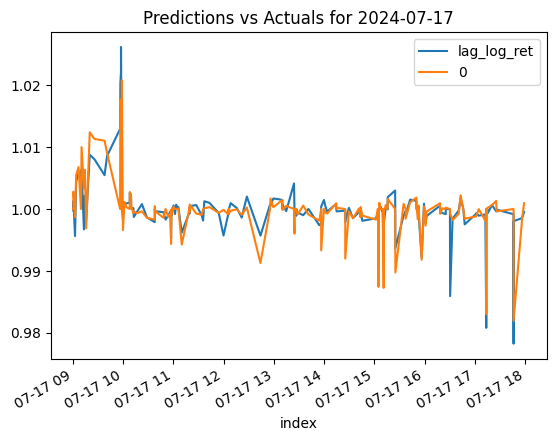

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-18:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     260.4
Date:                Thu, 22 Aug 2024   Prob (F-statistic):           2.88e-49
Time:                        13:01:57   Log-Likelihood:                 2743.4
No. Observations:                 631   AIC:                            -5483.
Df Residuals:                     629   BIC:                            -5474.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2

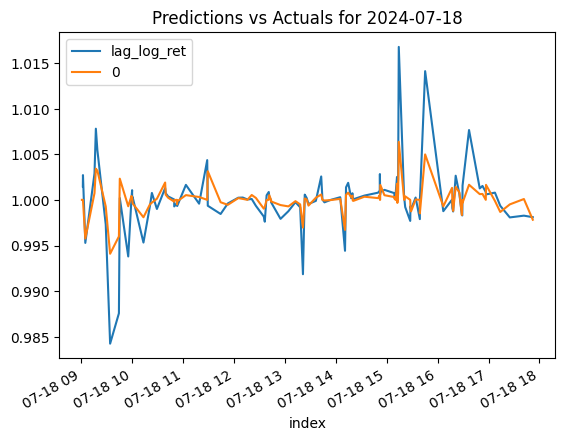

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-19:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     330.4
Date:                Thu, 22 Aug 2024   Prob (F-statistic):           2.97e-60
Time:                        13:01:57   Log-Likelihood:                 2916.5
No. Observations:                 668   AIC:                            -5829.
Df Residuals:                     666   BIC:                            -5820.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         4

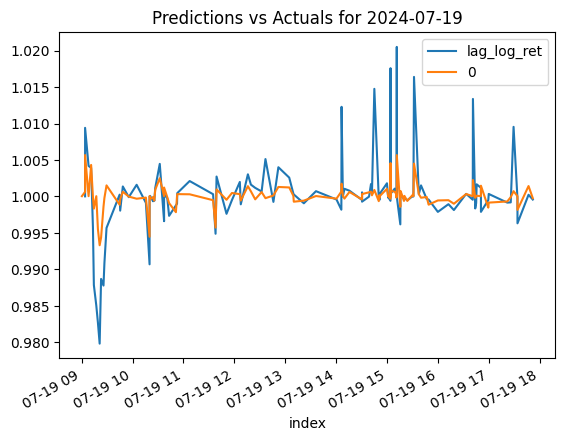

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-22:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.317
Method:                 Least Squares   F-statistic:                     321.5
Date:                Thu, 22 Aug 2024   Prob (F-statistic):           2.54e-59
Time:                        13:01:57   Log-Likelihood:                 2947.8
No. Observations:                 693   AIC:                            -5892.
Df Residuals:                     691   BIC:                            -5883.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         3

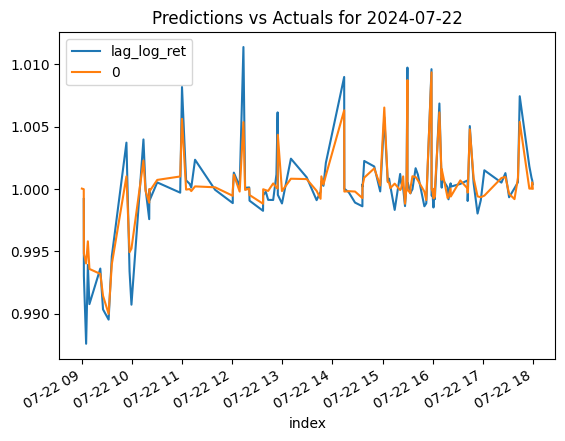

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-23:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     438.9
Date:                Thu, 22 Aug 2024   Prob (F-statistic):           5.20e-75
Time:                        13:01:57   Log-Likelihood:                 2819.7
No. Observations:                 658   AIC:                            -5635.
Df Residuals:                     656   BIC:                            -5626.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         3

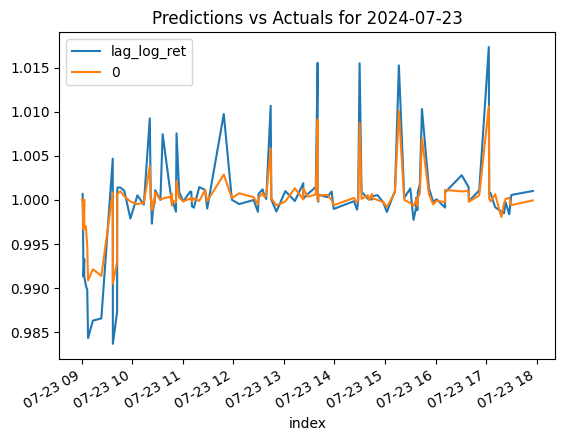

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-24:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                     594.1
Date:                Thu, 22 Aug 2024   Prob (F-statistic):           2.12e-93
Time:                        13:01:57   Log-Likelihood:                 2773.4
No. Observations:                 644   AIC:                            -5543.
Df Residuals:                     642   BIC:                            -5534.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         4

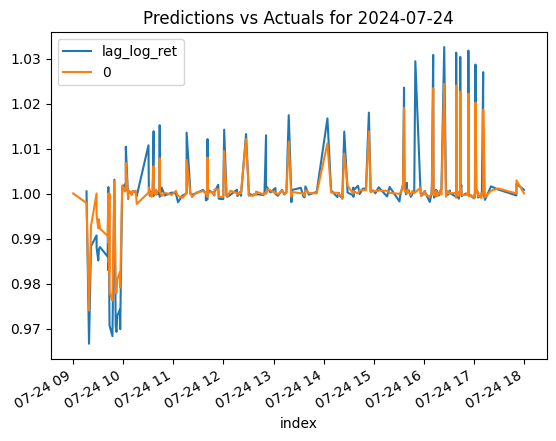

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-25:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     2542.
Date:                Thu, 22 Aug 2024   Prob (F-statistic):          8.72e-238
Time:                        13:01:57   Log-Likelihood:                 3134.7
No. Observations:                 718   AIC:                            -6265.
Df Residuals:                     716   BIC:                            -6256.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2

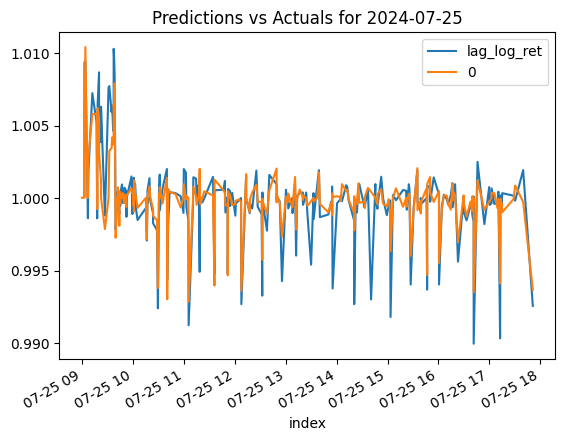

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-26:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     3128.
Date:                Thu, 22 Aug 2024   Prob (F-statistic):          1.24e-294
Time:                        13:01:57   Log-Likelihood:                 4007.2
No. Observations:                 899   AIC:                            -8010.
Df Residuals:                     897   BIC:                            -8001.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1

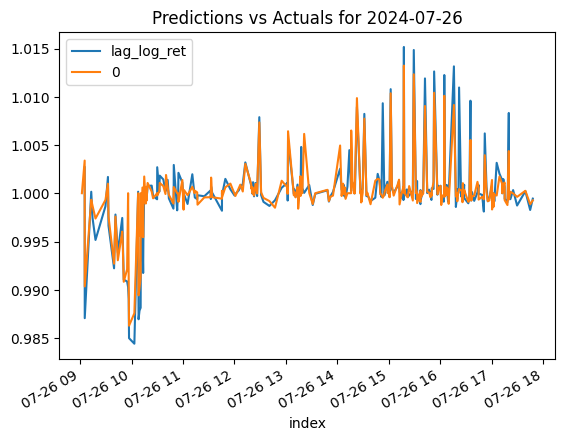

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-29:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     4707.
Date:                Thu, 22 Aug 2024   Prob (F-statistic):               0.00
Time:                        13:01:58   Log-Likelihood:                 4920.8
No. Observations:                1063   AIC:                            -9838.
Df Residuals:                    1061   BIC:                            -9828.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2

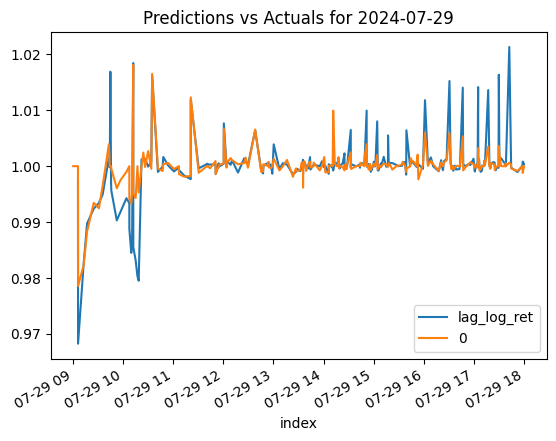

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-30:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     4038.
Date:                Thu, 22 Aug 2024   Prob (F-statistic):               0.00
Time:                        13:01:58   Log-Likelihood:                 5334.7
No. Observations:                1185   AIC:                        -1.067e+04
Df Residuals:                    1183   BIC:                        -1.066e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         4

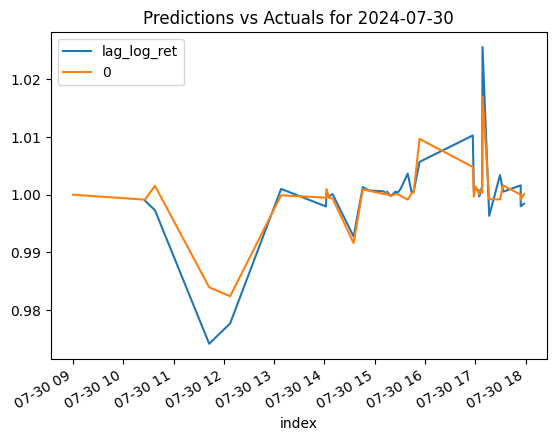

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\1098266827.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]


Summary for model on 2024-07-31:
                            OLS Regression Results                            
Dep. Variable:            lag_log_ret   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     3613.
Date:                Thu, 22 Aug 2024   Prob (F-statistic):               0.00
Time:                        13:01:58   Log-Likelihood:                 4919.3
No. Observations:                1102   AIC:                            -9835.
Df Residuals:                    1100   BIC:                            -9825.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1

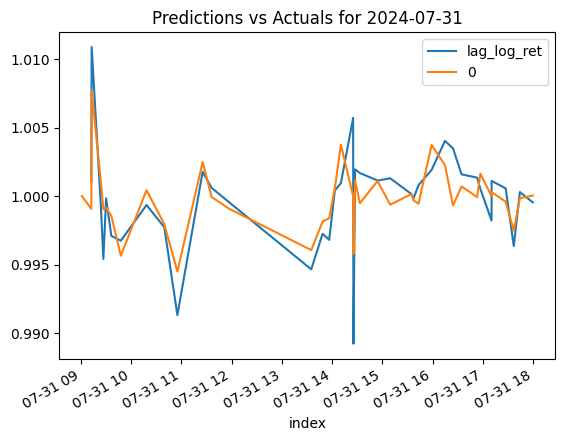

R-squared for the whole period: 0.5415425616384505



date
2024-07-25    291
2024-07-26    289
2024-07-24    248
2024-07-29    237
2024-07-17    174
2024-07-15    150
2024-07-16    134
2024-07-08    134
2024-07-09    125
2024-07-19    125
2024-07-23    120
2024-07-10    116
2024-07-22    115
2024-07-18    110
2024-07-02    109
2024-07-12    100
2024-07-01     74
2024-07-11     73
2024-07-03     69
2024-07-05     57
2024-07-04     56
2024-07-31     40
2024-07-30     37
Name: count, dtype: int64

In [48]:
# Define the number of previous days to use for the model
n_days = 5

# Prepare to store predictions
df_trds_indexed['lag_log_ret_pred'] = np.nan
df_trds_indexed['coef1'] = np.nan
df_trds_indexed['coef2'] = np.nan
df_trds_indexed['date']= df_trds_indexed.index.date
dates_list=sorted(list(set(df_trds_indexed['date'])))

# Loop through each day and fit the model using the previous n days
for current_day in dates_list[n_days:]:
    # Get the previous n days data
    start_day = dates_list[dates_list.index(current_day)-n_days]
    training_data = df_trds_indexed[start_day:current_day]
    
    # Skip if not enough data
    if len(training_data) < n_days:
        continue
    
    # Independent variable (lead_log_ret) and dependent variable (lag_log_ret)
    X_train = training_data['lead_log_ret'].fillna(0)
    y_train = training_data['lag_log_ret'].fillna(0)
    
    # Add a constant to the independent variable
    X_train = sm.add_constant(X_train)
    
    # Fit the model using statsmodels
    model = sm.OLS(y_train, X_train).fit()
    
    # Predict the lag_log_ret for the current day using the model
    X_test = sm.add_constant(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lead_log_ret'].fillna(0))
    df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lag_log_ret_pred'] = model.predict(X_test).fillna(0)
    df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef1'] = model.params[0]
    df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'coef2'] = model.params[1]

    r_squared_test = r2_score(df_trds_indexed.loc[df_trds_indexed['date']==current_day, 'lag_log_ret'].fillna(0), model.predict(X_test).fillna(0))

    # Optionally, print the summary for each model
    print(f"Summary for model on {current_day}:")
    print(model.summary())
    print(f"R-squared for the test period: {r_squared_test}\n")
    
    # Plotting
    pd.concat([np.exp(df_trds_indexed.loc[df_trds_indexed['date'] == current_day, 'lag_log_ret']),
               np.exp(model.predict(X_test))], axis=1).plot()
    plt.title(f'Predictions vs Actuals for {current_day}')
    plt.show()

r_squared_all = r2_score(df_trds_indexed.loc[:, 'lag_log_ret'].fillna(0), df_trds_indexed.loc[:, 'lag_log_ret_pred'].fillna(0))

# Display the DataFrame with predictions
print(f"R-squared for the whole period: {r_squared_all}\n")
df_trds_indexed['date'].value_counts()

# Production predicted price

In [49]:
df_trds['prev_tick_id']=df_trds['tick_id'].apply(lambda x: x.split('_')[0]+'_')+df_trds['tick_id'].apply(lambda x: str(float(x.split('_')[1])-1))

In [50]:
df_trds_indexed['lead_price_tick']=df_trds_indexed['lead_price']
df_trds_indexed['lag_price_tick']=df_trds_indexed['lag_price']
df_trds_indexed['prev_tick_id']=df_trds_indexed['tick_id']

In [51]:
df_trds

,trd_price,volume,bid_price,ask_price,mid_price,tag,lead_price,lead_volume,lead_pv,lag_price,lag_volume,lag_pv,date,tick_id,prev_tick_id
datetime,,,,,,,,,,,,,,,
2024-07-01 09:00:05.687479496,77.78,1.0,76.90,77.78,77.34,lead,77.78,1.0,77.78,NaN,NaN,NaN,2024-07-01,2024-07-01_0.0,2024-07-01_-1.0
2024-07-01 09:00:08.673907280,85.59,2.0,84.59,85.59,85.09,lag,NaN,NaN,NaN,85.59,2.0,171.18,2024-07-01,2024-07-01_0.0,2024-07-01_-1.0
2024-07-01 09:00:10.124257326,85.59,1.0,84.61,85.59,85.10,lag,NaN,NaN,NaN,85.59,1.0,85.59,2024-07-01,2024-07-01_0.0,2024-07-01_-1.0
2024-07-01 09:00:10.124334812,85.59,1.0,84.61,85.59,85.10,lag,NaN,NaN,NaN,85.59,1.0,85.59,2024-07-01,2024-07-01_0.0,2024-07-01_-1.0
2024-07-01 09:00:10.607145071,77.78,1.0,77.00,77.78,77.39,lead,77.78,1.0,77.78,NaN,NaN,NaN,2024-07-01,2024-07-01_0.0,2024-07-01_-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-31 17:59:24.314107895,83.62,1.0,83.63,83.69,83.66,lead,83.62,1.0,83.62,NaN,NaN,NaN,2024-07-31,2024-07-31_39.0,2024-07-31_38.0
2024-07-31 17:59:24.314178467,83.61,1.0,83.63,83.69,83.66,lead,83.61,1.0,83.61,NaN,NaN,NaN,2024-07-31,2024-07-31_39.0,2024-07-31_38.0
2024-07-31 17:59:26.323147058,85.90,1.0,85.88,85.96,85.92,lag,NaN,NaN,NaN,85.90,1.0,85.90,2024-07-31,2024-07-31_39.0,2024-07-31_38.0


In [52]:
df_trds=df_trds.reset_index().merge(df_trds_indexed[['prev_tick_id', 'lead_price_tick', 'lag_price_tick', 'coef1', 'coef2']], how='left', on='prev_tick_id')

In [53]:
df_trds_lead=df_trds[df_trds['tag']=='lead']

In [54]:
def predict_lag_price(lead_price_tick, lead_price, lag_price_tick, coef1, coef2):
    if all([lead_price_tick, lead_price, lag_price_tick, coef1, coef2]):
        return lag_price_tick*np.exp((coef1+coef2*np.log(lead_price/lead_price_tick)))
    else:
        return None

In [55]:
df_trds_lead['lag_price_predicted']=df_trds_lead[['lead_price_tick', 'lead_price', 'lag_price_tick', 'coef1', 'coef2']].apply(lambda row: predict_lag_price(row['lead_price_tick'], row['lead_price'], row['lag_price_tick'], row['coef1'], row['coef2']), axis=1)

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\3671564840.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trds_lead['lag_price_predicted']=df_trds_lead[['lead_price_tick', 'lead_price', 'lag_price_tick', 'coef1', 'coef2']].apply(lambda row: predict_lag_price(row['lead_price_tick'], row['lead_price'], row['lag_price_tick'], row['coef1'], row['coef2']), axis=1)


In [56]:
df_trds_lead[['datetime','lag_price_predicted']]

,datetime,lag_price_predicted
0,2024-07-01 09:00:05.687479496,NaN
4,2024-07-01 09:00:10.607145071,NaN
7,2024-07-01 09:00:21.248078108,NaN
8,2024-07-01 09:01:07.907927752,NaN
9,2024-07-01 09:01:17.118580341,NaN
...,...,...
56631,2024-07-31 17:56:10.052391529,86.042014
56633,2024-07-31 17:59:24.314107895,85.948580
56634,2024-07-31 17:59:24.314178467,85.939768
56636,2024-07-31 17:59:59.071200848,85.930955


In [57]:
df_trds_lead['lag_price_predicted_datetime']=df_trds_lead['datetime']

C:\Users\andrej\AppData\Local\Temp\ipykernel_5784\2327033080.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trds_lead['lag_price_predicted_datetime']=df_trds_lead['datetime']


In [58]:
data_lag=pd.merge_asof(data_lag,df_trds_lead[['datetime','lag_price_predicted','lag_price_predicted_datetime']], on='datetime', direction='backward')

In [59]:
df_trds_lead[-50:]

,datetime,trd_price,volume,bid_price,ask_price,mid_price,tag,lead_price,lead_volume,lead_pv,...,lag_pv,date,tick_id,prev_tick_id,lead_price_tick,lag_price_tick,coef1,coef2,lag_price_predicted,lag_price_predicted_datetime
56573,2024-07-31 17:43:38.113814592,83.6000,1.0,83.61,83.67,83.640,lead,83.6000,1.0,83.60,...,NaN,2024-07-31,2024-07-31_37.0,2024-07-31_36.0,83.863896,86.221667,0.000002,0.857361,85.989142,2024-07-31 17:43:38.113814592
56574,2024-07-31 17:43:38.124635935,83.6000,1.0,83.61,83.67,83.640,lead,83.6000,1.0,83.60,...,NaN,2024-07-31,2024-07-31_37.0,2024-07-31_36.0,83.863896,86.221667,0.000002,0.857361,85.989142,2024-07-31 17:43:38.124635935
56575,2024-07-31 17:43:38.135348320,83.6000,1.0,83.61,83.67,83.640,lead,83.6000,1.0,83.60,...,NaN,2024-07-31,2024-07-31_37.0,2024-07-31_36.0,83.863896,86.221667,0.000002,0.857361,85.989142,2024-07-31 17:43:38.135348320
56576,2024-07-31 17:43:38.146100760,83.6000,1.0,83.61,83.67,83.640,lead,83.6000,1.0,83.60,...,NaN,2024-07-31,2024-07-31_37.0,2024-07-31_36.0,83.863896,86.221667,0.000002,0.857361,85.989142,2024-07-31 17:43:38.146100760
56577,2024-07-31 17:43:38.156580925,83.6000,1.0,83.61,83.67,83.640,lead,83.6000,1.0,83.60,...,NaN,2024-07-31,2024-07-31_37.0,2024-07-31_36.0,83.863896,86.221667,0.000002,0.857361,85.989142,2024-07-31 17:43:38.156580925
56583,2024-07-31 17:44:01.226547241,83.6000,1.0,83.51,83.60,83.555,lead,83.6000,1.0,83.60,...,NaN,2024-07-31,2024-07-31_38.0,2024-07-31_37.0,83.618000,85.908000,0.000002,0.857361,85.892288,2024-07-31 17:44:01.226547241
56584,2024-07-31 17:44:01.226547241,83.6000,1.0,83.51,83.60,83.555,lead,83.6000,1.0,83.60,...,NaN,2024-07-31,2024-07-31_38.0,2024-07-31_37.0,83.618000,85.908000,0.000002,0.857361,85.892288,2024-07-31 17:44:01.226547241
56585,2024-07-31 17:44:38.366735458,83.6000,1.0,83.55,83.69,83.620,lead,83.6000,1.0,83.60,...,NaN,2024-07-31,2024-07-31_38.0,2024-07-31_37.0,83.618000,85.908000,0.000002,0.857361,85.892288,2024-07-31 17:44:38.366735458
56586,2024-07-31 17:48:38.165153742,83.6000,1.0,83.61,83.69,83.650,lead,83.6000,1.0,83.60,...,NaN,2024-07-31,2024-07-31_38.0,2024-07-31_37.0,83.618000,85.908000,0.000002,0.857361,85.892288,2024-07-31 17:48:38.165153742
56587,2024-07-31 17:48:59.771477938,83.6500,1.0,83.61,83.65,83.630,lead,83.6500,1.0,83.65,...,NaN,2024-07-31,2024-07-31_38.0,2024-07-31_37.0,83.618000,85.908000,0.000002,0.857361,85.936329,2024-07-31 17:48:59.771477938


In [60]:
data_lag[-50:]

,datetime,trd_price,volume,bid_price,ask_price,mid_price,lag_price_predicted,lag_price_predicted_datetime
123194,2024-07-31 17:56:31.000000000,NaN,NaN,85.89,86.17,86.030,86.042014,2024-07-31 17:56:10.052391529
123195,2024-07-31 17:56:32.000000000,NaN,NaN,85.89,86.14,86.015,86.042014,2024-07-31 17:56:10.052391529
123196,2024-07-31 17:56:34.000000000,NaN,NaN,85.89,86.16,86.025,86.042014,2024-07-31 17:56:10.052391529
123197,2024-07-31 17:56:35.000000000,NaN,NaN,85.89,86.17,86.030,86.042014,2024-07-31 17:56:10.052391529
123198,2024-07-31 17:56:36.000000000,NaN,NaN,85.89,86.16,86.025,86.042014,2024-07-31 17:56:10.052391529
123199,2024-07-31 17:56:37.000000000,NaN,NaN,85.89,86.15,86.020,86.042014,2024-07-31 17:56:10.052391529
123200,2024-07-31 17:56:39.000000000,NaN,NaN,85.89,86.14,86.015,86.042014,2024-07-31 17:56:10.052391529
123201,2024-07-31 17:56:41.000000000,NaN,NaN,85.89,86.16,86.025,86.042014,2024-07-31 17:56:10.052391529
123202,2024-07-31 17:56:42.000000000,NaN,NaN,85.89,86.15,86.020,86.042014,2024-07-31 17:56:10.052391529
123203,2024-07-31 17:56:43.000000000,NaN,NaN,85.89,86.16,86.025,86.042014,2024-07-31 17:56:10.052391529
